# Homework 1 — Evaluation & Comparison (4 Points)

Compare the two trained models (scratch vs pretrained) and analyze their performance.

**Tasks:**
1. Compare training curves side by side
2. Show confusion matrix for both models
3. Discuss: Which classes are hardest? Why?

**Deliverables:**
- 3 Jupyter notebooks exported as **HTML**
- 1-page **PDF report**: summarize results, comparison, and key observations

## Setup

In [1]:
import timm
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
)

NUM_CLASSES = 21
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Load Both Models and Test Data

In [ ]:
# TO-DONE: Load the scratch model — fill in the filename
model_scratch = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model_scratch.load_state_dict(torch.load("uc_merced_scratch.pth", map_location=device))
model_scratch = model_scratch.to(device)
model_scratch.eval()

# TO-DONE: Load the pretrained model — fill in the filename
model_pretrained = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model_pretrained.load_state_dict(torch.load("uc_merced_pretrained.pth", map_location=device))
model_pretrained = model_pretrained.to(device)
model_pretrained.eval()

# Test data
config = timm.data.resolve_model_data_config(model_scratch)
test_transform = timm.data.create_transform(**config, is_training=False)
test_ds = datasets.ImageFolder("PrepData/Test", transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

class_names = test_ds.classes
print(f"Test samples: {len(test_ds)}")
print(f"Classes: {class_names}")

Test samples: 315
Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


In [3]:
def get_predictions(model, loader):
    """Run inference, return (preds, labels)."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            all_preds.extend(model(images).argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_preds, all_labels

preds_scratch, labels_scratch = get_predictions(model_scratch, test_loader)
preds_pretrained, labels_pretrained = get_predictions(model_pretrained, test_loader)

print("=== From Scratch ===")
print(f"  Accuracy:          {accuracy_score(labels_scratch, preds_scratch):.2%}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(labels_scratch, preds_scratch):.2%}")

print("\n=== Pretrained ===")
print(f"  Accuracy:          {accuracy_score(labels_pretrained, preds_pretrained):.2%}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(labels_pretrained, preds_pretrained):.2%}")

=== From Scratch ===
  Accuracy:          33.97%
  Balanced Accuracy: 33.97%

=== Pretrained ===
  Accuracy:          96.51%
  Balanced Accuracy: 96.51%


## 2. Training Curves: Side by Side

Load the training history CSVs saved by `01_TrainModel.ipynb`.

In [5]:
# TO-DONE: Fill in the CSV filenames saved by 01_TrainModel.ipynb
history_scratch = pd.read_csv("history_scratch.csv").to_dict(orient="list")
history_pretrained = pd.read_csv("history_pretrained.csv").to_dict(orient="list")

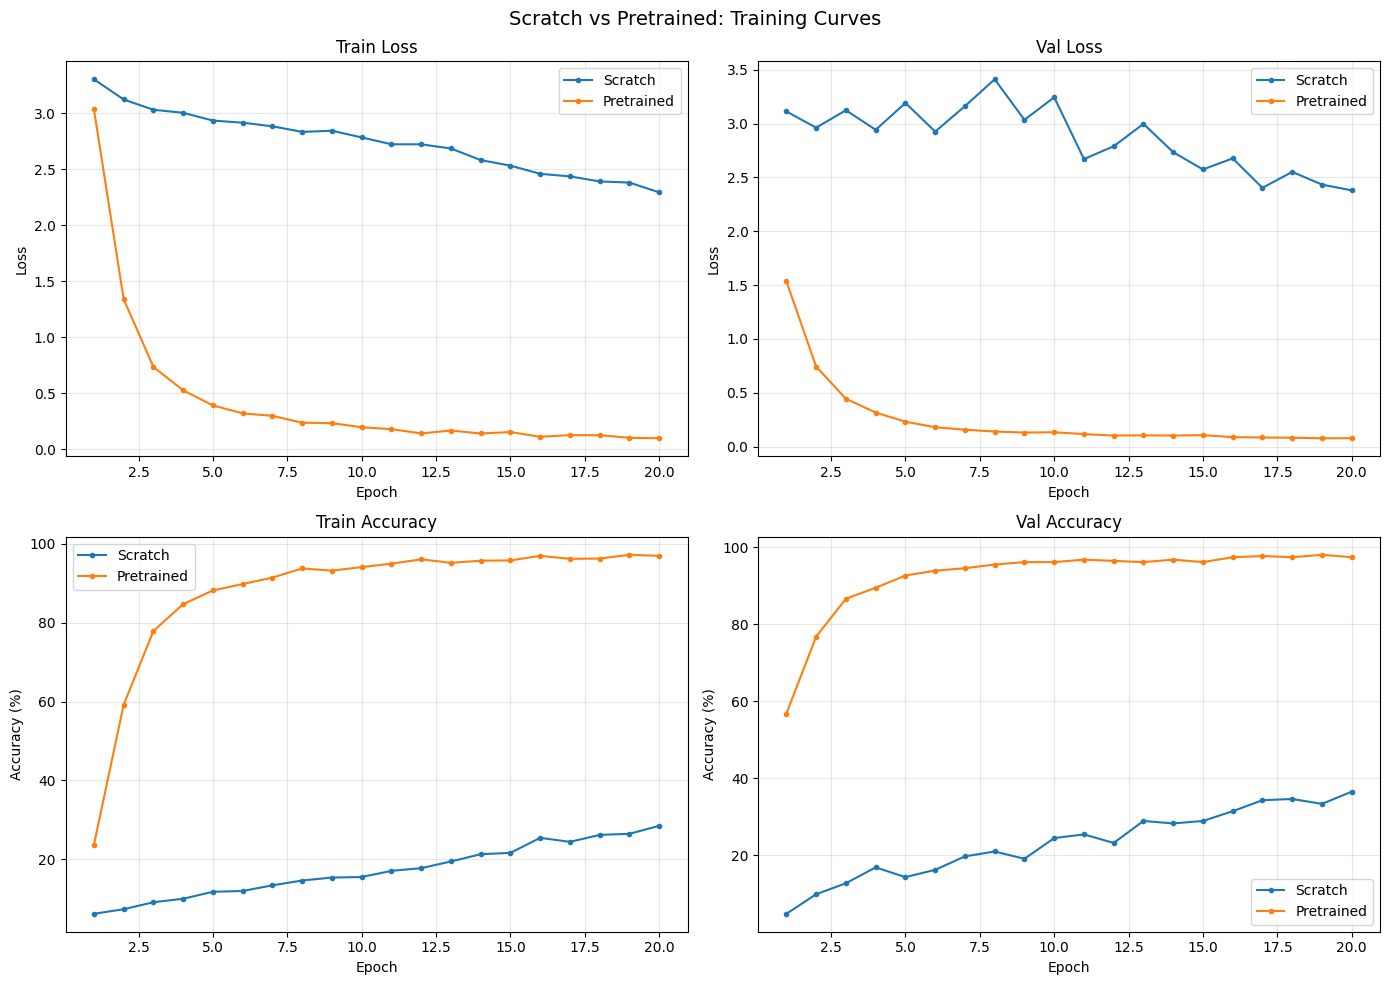

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep_s = range(1, len(history_scratch["train_loss"]) + 1)
ep_p = range(1, len(history_pretrained["train_loss"]) + 1)

titles = ["Train Loss", "Val Loss", "Train Accuracy", "Val Accuracy"]
keys = ["train_loss", "val_loss", "train_acc", "val_acc"]
ylabels = ["Loss", "Loss", "Accuracy (%)", "Accuracy (%)"]

for ax, title, key, ylabel in zip(axes.flatten(), titles, keys, ylabels):
    ax.plot(ep_s, history_scratch[key], label="Scratch", marker='o', ms=3)
    ax.plot(ep_p, history_pretrained[key], label="Pretrained", marker='o', ms=3)
    ax.set(xlabel="Epoch", ylabel=ylabel, title=title)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Scratch vs Pretrained: Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Confusion Matrices

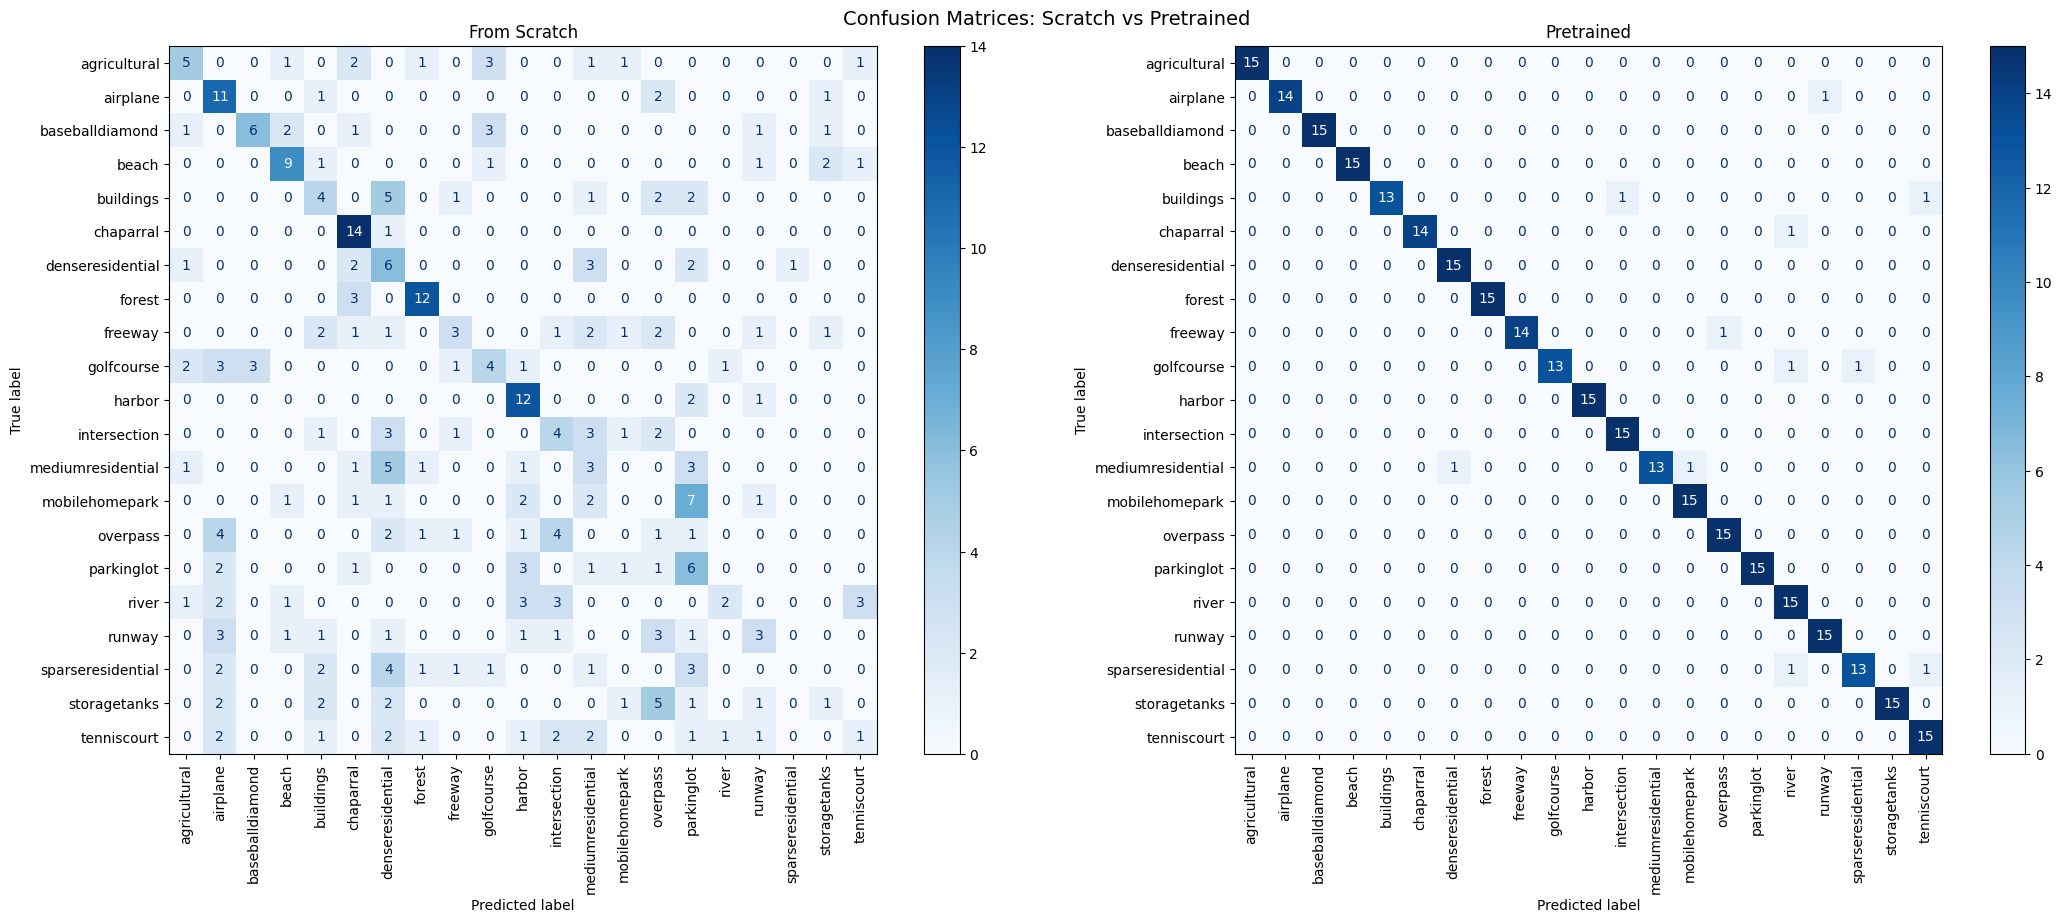

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

cm_scratch = confusion_matrix(labels_scratch, preds_scratch)
ConfusionMatrixDisplay(cm_scratch, display_labels=class_names).plot(
    cmap=plt.cm.Blues, ax=ax1, xticks_rotation=90)
ax1.set_title("From Scratch")

cm_pretrained = confusion_matrix(labels_pretrained, preds_pretrained)
ConfusionMatrixDisplay(cm_pretrained, display_labels=class_names).plot(
    cmap=plt.cm.Blues, ax=ax2, xticks_rotation=90)
ax2.set_title("Pretrained")

fig.suptitle("Confusion Matrices: Scratch vs Pretrained", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
print("=== Classification Report: From Scratch ===")
print(classification_report(labels_scratch, preds_scratch, target_names=class_names))

print("\n=== Classification Report: Pretrained ===")
print(classification_report(labels_pretrained, preds_pretrained, target_names=class_names))

=== Classification Report: From Scratch ===
                   precision    recall  f1-score   support

     agricultural       0.45      0.33      0.38        15
         airplane       0.35      0.73      0.48        15
  baseballdiamond       0.67      0.40      0.50        15
            beach       0.60      0.60      0.60        15
        buildings       0.27      0.27      0.27        15
        chaparral       0.54      0.93      0.68        15
 denseresidential       0.18      0.40      0.25        15
           forest       0.71      0.80      0.75        15
          freeway       0.38      0.20      0.26        15
       golfcourse       0.33      0.27      0.30        15
           harbor       0.48      0.80      0.60        15
     intersection       0.27      0.27      0.27        15
mediumresidential       0.16      0.20      0.18        15
   mobilehomepark       0.00      0.00      0.00        15
         overpass       0.06      0.07      0.06        15
       park

## 4. Discussion

**a) Accuracy & Convergence:**
- Which model achieves higher test accuracy?
- Which model converges faster (reaches good validation accuracy sooner)?

**b) Hardest Classes:**
- Which classes have the lowest F1-score for each model?
- Which classes get confused with each other? (look at the confusion matrix)
- Why? (think about visual similarity, e.g., `dense_residential` vs `medium_residential`)

**c) Pretrained vs Scratch:**
- Why does transfer learning help (or not) for this dataset?
- Are there classes where one model does better than the other?